## gRNA mismatch analysis
This will tell us how many gRNAs per gene have a gRNA that might tolerate a single base pair mismatch and therefore not be allele-specific in the way we wish

In [1]:
import numpy as np
import pandas as pd
import pickle
import os

In [2]:
results_dir = '/wynton/home/capra/gramey02/dnd_project/results'
run_name = 'RUN_MULTIALLELIC'
strats=['indels','CRISPRoff','base_edits','excision']
excavate_dir='excavate/excavate_outputs'

## Rerun
A>G + alt
C>T - ref
G>A + ref
T>C - alt

Expected 30-50% of gRNAs will be able to rescue
Expected 10% major mismatch presence

Base editor snp targeting cannot be rescued (for both donor and acceptor)

Look into cell type and assay

In [3]:
from tqdm.auto import tqdm

KEEP = {
    ('A>G', '+', 'alt'),
    ('C>T', '-', 'ref'),
    ('G>A', '+', 'ref'),
    ('T>C', '-', 'alt'),
}


def count_mismatch_grnas(grnas):
    """Return (total, n_mismatch_tolerant) for one gene's guide table."""
    total = len(grnas)
    allele_type = grnas['present allele'].str.extract(r'\((ref|alt)\)', expand=False)
    mask = pd.Series(
        list(zip(grnas['variation'], grnas['strand'], allele_type)),
        index=grnas.index,
    ).isin(KEEP)
    return total, int(mask.sum())


def load_guides(*path_parts):
    fp = os.path.join(*path_parts, 'all_guides.csv')
    return pd.read_csv(fp) if os.path.exists(fp) else None


results = {}
proportion_results = {}
skipped = {}  # strat -> list of genes with no guide file

for strat in tqdm(strats, desc='strategies'):
    strat_result = {}
    strat_prop_results = {}
    strat_skipped = []

    if strat != 'base_edits':
        cur_fp = os.path.join(results_dir, run_name, strat, excavate_dir)
        cur_outputs = sorted(os.listdir(cur_fp))

        for file in tqdm(cur_outputs, desc=strat, leave=False):
            cur_gene = file.split('_')[0]
            grnas = load_guides(cur_fp, file)
            if grnas is None:
                strat_skipped.append(cur_gene)
                continue
            total, n_mm = count_mismatch_grnas(grnas)
            strat_result[cur_gene] = {
                'total_grnas': total,
                'total_mismatch_grnas': n_mm,
            }
            strat_prop_results[cur_gene] = n_mm / total if total > 0 else np.nan

    else:
        cur_fp_acc = os.path.join(results_dir, run_name, 'acceptor_base_edits', excavate_dir)
        cur_fp_donor = os.path.join(results_dir, run_name, 'donor_base_edits', excavate_dir)

        acc_genes = {x.split('_')[0] for x in os.listdir(cur_fp_acc)}
        donor_genes = {x.split('_')[0] for x in os.listdir(cur_fp_donor)}
        all_base_edit_genes = sorted(acc_genes | donor_genes)

        for gene in tqdm(all_base_edit_genes, desc=strat, leave=False):
            frames = [
                df for df in (
                    load_guides(cur_fp_acc, gene + '_output'),
                    load_guides(cur_fp_donor, gene + '_output'),
                )
                if df is not None
            ]
            if not frames:
                strat_skipped.append(gene)
                continue
            base_edit_grnas = pd.concat(frames, ignore_index=True).drop_duplicates()

            total, n_mm = count_mismatch_grnas(base_edit_grnas)
            strat_result[gene] = {
                'total_grnas': total,
                'total_mismatch_grnas': n_mm,
            }
            strat_prop_results[gene] = n_mm / total if total > 0 else np.nan

    results[strat] = strat_result
    proportion_results[strat] = strat_prop_results
    skipped[strat] = strat_skipped

    tqdm.write(
        f'{strat}: {len(strat_result)} genes processed, '
        f'{len(strat_skipped)} skipped (no all_guides.csv)'
    )

strategies:   0%|          | 0/4 [00:00<?, ?it/s]

indels:   0%|          | 0/218 [00:00<?, ?it/s]

indels: 218 genes processed, 0 skipped (no all_guides.csv)


CRISPRoff:   0%|          | 0/240 [00:00<?, ?it/s]

CRISPRoff: 240 genes processed, 0 skipped (no all_guides.csv)


base_edits:   0%|          | 0/168 [00:00<?, ?it/s]

/scratch/gramey02/ipykernel_608025/577290473.py:72: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  base_edit_grnas = pd.concat(frames, ignore_index=True).drop_duplicates()
/scratch/gramey02/ipykernel_608025/577290473.py:72: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  base_edit_grnas = pd.concat(frames, ignore_index=True).drop_duplicates()
/scratch/gramey02/ipykernel_608025/577290473.py:72: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a fu

base_edits: 168 genes processed, 0 skipped (no all_guides.csv)


excision:   0%|          | 0/537 [00:00<?, ?it/s]

excision: 537 genes processed, 0 skipped (no all_guides.csv)


In [4]:
# print out some summary stats
proportion_results
# this is telling us what fraction of a gene's gRNAs were the most tolerated rG:dT mismatch

{'indels': {'AARS1': 0.25,
  'ABCC8': 0.0,
  'ACO2': 0.25,
  'ACTA1': 0.4375,
  'ACTG1': 0.3157894736842105,
  'ACTL6A': nan,
  'ACTN1': 1.0,
  'ACVR1': 0.4444444444444444,
  'ADAR': 0.5,
  'AFG3L2': 0.14285714285714285,
  'AGO2': 0.5555555555555556,
  'AICDA': 0.5,
  'ALK': 0.0,
  'ALPK3': 0.2,
  'ALPL': 0.4444444444444444,
  'ANO5': nan,
  'ANXA11': 0.3333333333333333,
  'AP1G1': 0.0,
  'AP2M1': 0.0,
  'ATL1': 0.6666666666666666,
  'ATL3': 0.0,
  'ATP1A1': 0.0,
  'ATP1A2': 0.42857142857142855,
  'ATP2B2': 0.42857142857142855,
  'BACH2': nan,
  'BICRA': 0.2222222222222222,
  'BSCL2': 0.2,
  'C3': 0.3333333333333333,
  'CACNA1C': 0.18181818181818182,
  'CACNA1E': 0.2,
  'CACNA1S': 0.21875,
  'CALM1': 0.6,
  'CARD11': 0.25,
  'CASQ2': nan,
  'CCND2': 0.0,
  'CEACAM16': 0.6666666666666666,
  'CEL': 0.2,
  'CFB': 0.38095238095238093,
  'CFH': 0.2,
  'CHCHD10': 0.375,
  'CHMP2B': 0.0,
  'CHRNA4': 0.35294117647058826,
  'CHRNB2': 0.4,
  'CLCN7': 0.3333333333333333,
  'COL1A2': 0.0625,
  'CO

In [5]:
# print out some summary stats
results

{'indels': {'AARS1': {'total_grnas': 4, 'total_mismatch_grnas': 1},
  'ABCC8': {'total_grnas': 6, 'total_mismatch_grnas': 0},
  'ACO2': {'total_grnas': 12, 'total_mismatch_grnas': 3},
  'ACTA1': {'total_grnas': 16, 'total_mismatch_grnas': 7},
  'ACTG1': {'total_grnas': 19, 'total_mismatch_grnas': 6},
  'ACTL6A': {'total_grnas': 0, 'total_mismatch_grnas': 0},
  'ACTN1': {'total_grnas': 1, 'total_mismatch_grnas': 1},
  'ACVR1': {'total_grnas': 9, 'total_mismatch_grnas': 4},
  'ADAR': {'total_grnas': 2, 'total_mismatch_grnas': 1},
  'AFG3L2': {'total_grnas': 14, 'total_mismatch_grnas': 2},
  'AGO2': {'total_grnas': 9, 'total_mismatch_grnas': 5},
  'AICDA': {'total_grnas': 2, 'total_mismatch_grnas': 1},
  'ALK': {'total_grnas': 8, 'total_mismatch_grnas': 0},
  'ALPK3': {'total_grnas': 5, 'total_mismatch_grnas': 1},
  'ALPL': {'total_grnas': 9, 'total_mismatch_grnas': 4},
  'ANO5': {'total_grnas': 0, 'total_mismatch_grnas': 0},
  'ANXA11': {'total_grnas': 6, 'total_mismatch_grnas': 2},
  'A

In [6]:
# then let's get a readout of per-gene/strategy combination, how often this happens:
per_strat_prop = {}
for strat, strat_result in proportion_results.items():
    per_strat_prop[strat] = np.nanmean(list(strat_result.values()))
print(np.mean(list(per_strat_prop.values())))
per_strat_prop

0.2789471732693106


{'indels': np.float64(0.3345227812594349),
 'CRISPRoff': np.float64(0.24012466354493608),
 'base_edits': np.float64(0.28507778524111155),
 'excision': np.float64(0.2560634630317601)}

## This means that generally about a tenth of the gRNAs have this mismatch tolerance

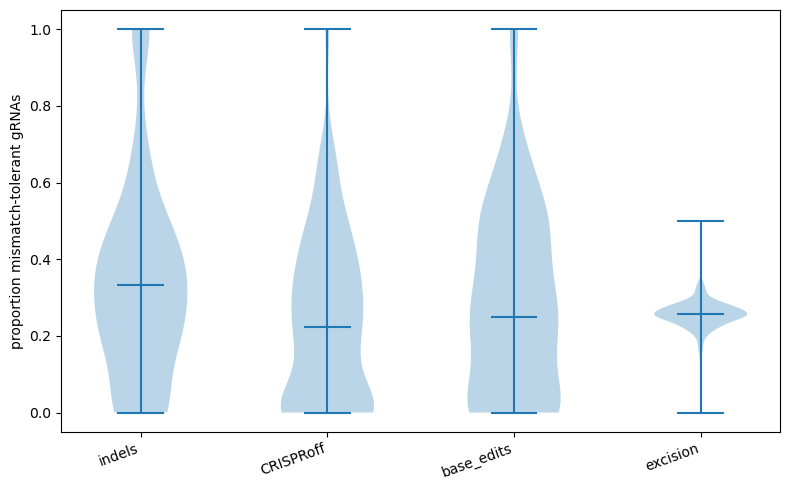

In [10]:
# plot the results
import matplotlib.pyplot as plt

all_strat_props=[]
for strats, strat_result in results.items():
    strat_props=[]
    for gene, result_dict in strat_result.items():
        if result_dict['total_grnas']!=0:
            strat_props.append(result_dict['total_mismatch_grnas']/result_dict['total_grnas'])
    all_strat_props.append(strat_props)

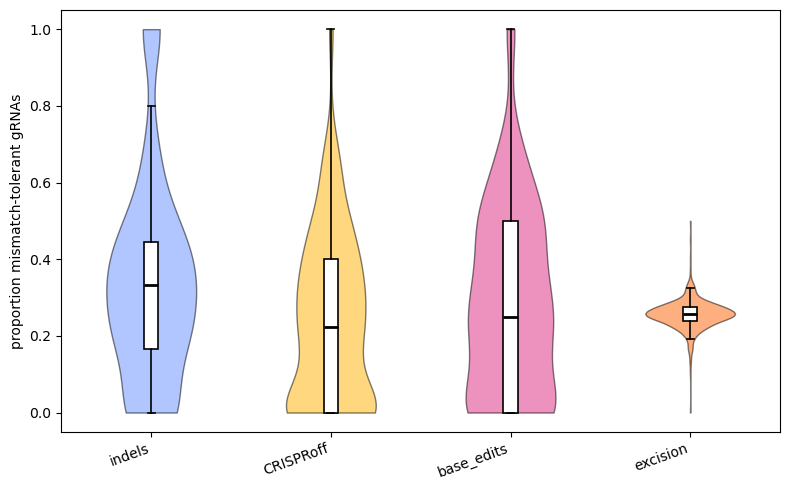

In [14]:
import numpy as np
import matplotlib.pyplot as plt

COLORS = {
    'base_edits': '#DC267F',   # splice site disruption
    'indels':     '#648FFF',   # exon disruption
    'CRISPRoff':  '#FFB000',   # epigenetic silencing
    'excision':   '#FE6100',   # excision
}

strat_names = []
all_strat_props = []

for strat_name, strat_result in results.items():
    props = [
        d['total_mismatch_grnas'] / d['total_grnas']
        for d in strat_result.values()
        if d['total_grnas'] > 0
    ]
    if not props:
        continue
    strat_names.append(strat_name)
    all_strat_props.append(props)

fig, ax = plt.subplots(figsize=(8, 5))

parts = ax.violinplot(all_strat_props, showmedians=False, showextrema=False)
for name, body in zip(strat_names, parts['bodies']):
    body.set_facecolor(COLORS.get(name, 'grey'))
    body.set_edgecolor('black')
    body.set_alpha(0.5)

ax.boxplot(
    all_strat_props,
    widths=0.08,
    patch_artist=True,                                   # needed to fill the box
    showfliers=False,
    whis=1.5,                                            # 1.5 x IQR whiskers
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.2),
    whiskerprops=dict(color='black', linewidth=1.2),
    capprops=dict(color='black', linewidth=1.2),
    medianprops=dict(color='black', linewidth=2),
    zorder=3,                                            # keep box above violin
)

ax.set_xticks(range(1, len(strat_names) + 1))
ax.set_xticklabels(strat_names, rotation=20, ha='right')
ax.set_ylabel('proportion mismatch-tolerant gRNAs')
plt.tight_layout()
plt.savefig("/wynton/home/capra/gramey02/dnd_project/data/figs/rG_dT_mismatch_proportions.svg", dpi=300, bbox_inches='tight')
plt.show()


In [13]:
for name, arr in zip(strat_names, all_strat_props):
    a = np.asarray(arr)
    q1, q3 = np.percentile(a, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    w_lo = a[a >= lo].min()
    w_hi = a[a <= hi].max()
    print(f'{name:12s} Q1={q1:.3f} Q3={q3:.3f} IQR={iqr:.3f} '
          f'fences=[{lo:.3f}, {hi:.3f}] whiskers=[{w_lo:.3f}, {w_hi:.3f}] '
          f'range=[{a.min():.3f}, {a.max():.3f}] n_outliers={(a > hi).sum() + (a < lo).sum()}')

indels       Q1=0.167 Q3=0.444 IQR=0.278 fences=[-0.250, 0.861] whiskers=[0.000, 0.800] range=[0.000, 1.000] n_outliers=14
CRISPRoff    Q1=0.000 Q3=0.400 IQR=0.400 fences=[-0.600, 1.000] whiskers=[0.000, 1.000] range=[0.000, 1.000] n_outliers=0
base_edits   Q1=0.000 Q3=0.500 IQR=0.500 fences=[-0.750, 1.250] whiskers=[0.000, 1.000] range=[0.000, 1.000] n_outliers=0
excision     Q1=0.239 Q3=0.274 IQR=0.035 fences=[0.187, 0.327] whiskers=[0.191, 0.326] range=[0.000, 0.500] n_outliers=35


## Let's also check whether, if this occurs, if the same snp has a non-mismatch tolerating gRNA as an option
e.g., like (some sort of more reliable backup option)

In [17]:
results_dir = '/wynton/home/capra/gramey02/dnd_project/results'
run_name = 'RUN_MULTIALLELIC'
strats=['indels','CRISPRoff','base_edits','excision']
excavate_dir='excavate/excavate_outputs'
MISMATCH = {
    ('A>G', '+', 'alt'),
    ('C>T', '-', 'ref'),
    ('G>A', '+', 'ref'),
    ('T>C', '-', 'alt'),
}

OPPOSITE = {'+': '-', '-': '+'}

SNP_KEY = ['chrom', 'SNP position']   # or ['rsID']


def annotate_keys(grnas):
    """Add allele type and a (variation, strand, allele) key column."""
    df = grnas.copy()
    df['allele type'] = df['present allele'].str.extract(r'\((ref|alt)\)', expand=False)
    for col in ('variation', 'strand'):
        df[col] = df[col].astype(str).str.strip()
    df['guide key'] = pd.Series(
        list(zip(df['variation'], df['strand'], df['allele type'])),
        index=df.index,
    )
    return df


def snp_alternative_rate(grnas, alternatives_possible=True):
    """
    Count SNPs carrying at least one mismatch-tolerant guide, and how many of
    those have the strand-flipped counterpart guide available.

    alternatives_possible=False (base editing): the counterpart is not a usable
    guide, so the covered count is 0 by construction and no search is done.

    Returns (n_snps_with_alternative, n_mismatch_snps).
    """
    df = annotate_keys(grnas)

    covered = 0
    n_mismatch_snps = 0

    for _, sub in df.groupby(SNP_KEY, dropna=False):
        keys = set(sub['guide key'])
        mm_keys = keys & MISMATCH
        if not mm_keys:
            continue

        n_mismatch_snps += 1

        if not alternatives_possible:
            continue

        needed = {(var, OPPOSITE[strand], allele) for var, strand, allele in mm_keys}
        if needed <= keys:
            covered += 1

    return covered, n_mismatch_snps


def load_guides(*path_parts):
    fp = os.path.join(*path_parts, 'all_guides.csv')
    return pd.read_csv(fp) if os.path.exists(fp) else None


snp_results = {}
snp_counts = {}
skipped = {}

for strat in tqdm(strats, desc='strategies'):
    strat_result = {}
    strat_counts = {}
    strat_skipped = []

    alternatives_possible = (strat != 'base_edits')

    if strat != 'base_edits':
        cur_fp = os.path.join(results_dir, run_name, strat, excavate_dir)
        cur_outputs = sorted(os.listdir(cur_fp))

        for file in tqdm(cur_outputs, desc=strat, leave=False):
            cur_gene = file.split('_')[0]
            grnas = load_guides(cur_fp, file)
            if grnas is None:
                strat_skipped.append(cur_gene)
                continue

            covered, n_mm_snps = snp_alternative_rate(
                grnas, alternatives_possible=alternatives_possible
            )
            strat_counts[cur_gene] = {
                'mismatch_snps': n_mm_snps,
                'snps_with_alternative': covered,
                'alternatives_possible': alternatives_possible,
            }
            strat_result[cur_gene] = covered / n_mm_snps if n_mm_snps > 0 else np.nan

    else:
        cur_fp_acc = os.path.join(results_dir, run_name, 'acceptor_base_edits', excavate_dir)
        cur_fp_donor = os.path.join(results_dir, run_name, 'donor_base_edits', excavate_dir)

        acc_genes = {x.split('_')[0] for x in os.listdir(cur_fp_acc)}
        donor_genes = {x.split('_')[0] for x in os.listdir(cur_fp_donor)}
        all_base_edit_genes = sorted(acc_genes | donor_genes)

        for gene in tqdm(all_base_edit_genes, desc=strat, leave=False):
            frames = [
                df for df in (
                    load_guides(cur_fp_acc, gene + '_output'),
                    load_guides(cur_fp_donor, gene + '_output'),
                )
                if df is not None
            ]
            if not frames:
                strat_skipped.append(gene)
                continue

            base_edit_grnas = pd.concat(frames, ignore_index=True).drop_duplicates()

            covered, n_mm_snps = snp_alternative_rate(
                base_edit_grnas, alternatives_possible=alternatives_possible
            )
            strat_counts[gene] = {
                'mismatch_snps': n_mm_snps,
                'snps_with_alternative': covered,
                'alternatives_possible': alternatives_possible,
            }
            strat_result[gene] = covered / n_mm_snps if n_mm_snps > 0 else np.nan

    snp_results[strat] = strat_result
    snp_counts[strat] = strat_counts
    skipped[strat] = strat_skipped

    tqdm.write(
        f'{strat}: {len(strat_result)} genes, '
        f'{len(strat_skipped)} skipped (no all_guides.csv)'
        + ('' if alternatives_possible else '  [alternatives N/A for this strategy]')
    )

strategies:   0%|          | 0/4 [00:00<?, ?it/s]

indels:   0%|          | 0/218 [00:00<?, ?it/s]

indels: 218 genes, 0 skipped (no all_guides.csv)


CRISPRoff:   0%|          | 0/240 [00:00<?, ?it/s]

CRISPRoff: 240 genes, 0 skipped (no all_guides.csv)


base_edits:   0%|          | 0/168 [00:00<?, ?it/s]

/scratch/gramey02/ipykernel_608025/2610719453.py:120: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  base_edit_grnas = pd.concat(frames, ignore_index=True).drop_duplicates()
/scratch/gramey02/ipykernel_608025/2610719453.py:120: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  base_edit_grnas = pd.concat(frames, ignore_index=True).drop_duplicates()
/scratch/gramey02/ipykernel_608025/2610719453.py:120: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. I

base_edits: 168 genes, 0 skipped (no all_guides.csv)  [alternatives N/A for this strategy]


excision:   0%|          | 0/537 [00:00<?, ?it/s]

excision: 537 genes, 0 skipped (no all_guides.csv)


In [18]:
snp_counts

{'indels': {'AARS1': {'mismatch_snps': 1,
   'snps_with_alternative': 1,
   'alternatives_possible': True},
  'ABCC8': {'mismatch_snps': 0,
   'snps_with_alternative': 0,
   'alternatives_possible': True},
  'ACO2': {'mismatch_snps': 1,
   'snps_with_alternative': 0,
   'alternatives_possible': True},
  'ACTA1': {'mismatch_snps': 2,
   'snps_with_alternative': 2,
   'alternatives_possible': True},
  'ACTG1': {'mismatch_snps': 2,
   'snps_with_alternative': 2,
   'alternatives_possible': True},
  'ACTL6A': {'mismatch_snps': 0,
   'snps_with_alternative': 0,
   'alternatives_possible': True},
  'ACTN1': {'mismatch_snps': 1,
   'snps_with_alternative': 0,
   'alternatives_possible': True},
  'ACVR1': {'mismatch_snps': 1,
   'snps_with_alternative': 1,
   'alternatives_possible': True},
  'ADAR': {'mismatch_snps': 1,
   'snps_with_alternative': 0,
   'alternatives_possible': True},
  'AFG3L2': {'mismatch_snps': 1,
   'snps_with_alternative': 1,
   'alternatives_possible': True},
  'AGO2': 

In [19]:
import pandas as pd
import numpy as np

# tidy long frame: one row per (strategy, gene)
rows = []
for strat, genes in snp_counts.items():
    for gene, c in genes.items():
        rows.append({
            'strategy': strat,
            'gene': gene,
            'mismatch_snps': c['mismatch_snps'],
            'snps_with_alternative': c['snps_with_alternative'],
            'alternatives_possible': c['alternatives_possible'],
        })

counts = pd.DataFrame(rows)
counts['gene_rate'] = np.where(
    counts['mismatch_snps'] > 0,
    counts['snps_with_alternative'] / counts['mismatch_snps'],
    np.nan,
)

summary = counts.groupby('strategy').apply(
    lambda g: pd.Series({
        'n_genes': len(g),
        'n_genes_with_mismatch_snps': int((g['mismatch_snps'] > 0).sum()),
        'total_mismatch_snps': int(g['mismatch_snps'].sum()),
        'total_snps_with_alternative': int(g['snps_with_alternative'].sum()),
        # pooled: every SNP weighted equally
        'pooled_rate': (
            g['snps_with_alternative'].sum() / g['mismatch_snps'].sum()
            if g['mismatch_snps'].sum() > 0 else np.nan
        ),
        # macro: every gene weighted equally
        'mean_gene_rate': g['gene_rate'].mean(),   # skips NaN by default
        'median_gene_rate': g['gene_rate'].median(),
        'alternatives_possible': g['alternatives_possible'].all(),
    }),
    include_groups=False,
).reset_index()

summary

,strategy,n_genes,n_genes_with_mismatch_snps,total_mismatch_snps,total_snps_with_alternative,pooled_rate,mean_gene_rate,median_gene_rate,alternatives_possible
0,CRISPRoff,240,155,247,135,0.546559,0.550430,0.500000,True
1,base_edits,168,103,148,0,0.000000,0.000000,0.000000,False
2,excision,537,536,53028,19694,0.371389,0.386663,0.383199,True
3,indels,218,164,277,149,0.537906,0.522285,0.500000,True


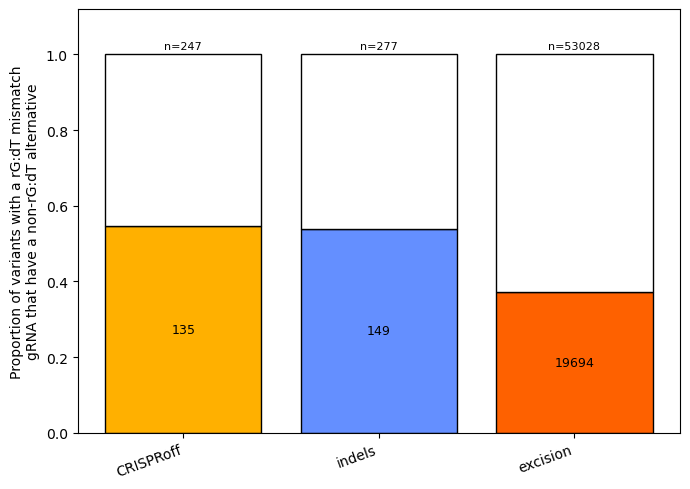

In [23]:
# plot total mismatch snps and total_snps_with_alternative
COLORS = {
    'indels':     '#648FFF',   # exon disruption
    'CRISPRoff':  '#FFB000',   # epigenetic silencing
    'excision':   '#FE6100',   # excision
}

d = summary[summary['alternatives_possible']].copy()          # drops base_edits
d['prop'] = d['total_snps_with_alternative'] / d['total_mismatch_snps']
d = d.sort_values('prop', ascending=False).reset_index(drop=True)

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(x, d['prop'],
       color=[COLORS.get(s, 'grey') for s in d['strategy']],
       edgecolor='black', linewidth=1)
ax.bar(x, 1 - d['prop'], bottom=d['prop'],
       color='white', edgecolor='black', linewidth=1)

for i, row in d.iterrows():
    ax.text(i, row['prop'] / 2,
            f"{row['total_snps_with_alternative']}",
            ha='center', va='center', fontsize=9)
    ax.text(i, 1.01,
            f"n={row['total_mismatch_snps']}",
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(d['strategy'], rotation=20, ha='right')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Proportion of variants with a rG:dT mismatch\ngRNA that have a non-rG:dT alternative')
plt.tight_layout()
plt.savefig("/wynton/home/capra/gramey02/dnd_project/data/figs/rG_dT_mismatch_alternatives.svg", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
calc_mean=[]
for idx,row in summary.iterrows():
    print(row.strategy)
    print(row.pooled_rate)
    if row.strategy!='base_edits':
        calc_mean.append(row.pooled_rate)

CRISPRoff
0.5465587044534413
base_edits
0.0
excision
0.37138870030927057
indels
0.5379061371841155


In [17]:
# average across strats
np.mean(calc_mean)

np.float64(0.48528451398227573)